In [ ]:
import kagglehub
import shutil
import os

# Download latest version
path = kagglehub.dataset_download("wcukierski/enron-email-dataset")

print("Path to dataset files:", path)

# Construct the full path to emails.csv within the downloaded dataset
source_file = os.path.join(path, "emails.csv")
destination_file = "/content/emails.csv"

# Move the file to /content/
if os.path.exists(source_file):
    shutil.move(source_file, destination_file)
    print(f"Moved {source_file} to {destination_file}")
else:
    print(f"Warning: emails.csv not found at {source_file}. Please check the dataset structure.")

100%|██████████| 358M/358M [00:04<00:00, 81.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/wcukierski/enron-email-dataset/versions/2
Moved /root/.cache/kagglehub/datasets/wcukierski/enron-email-dataset/versions/2/emails.csv to /content/emails.csv


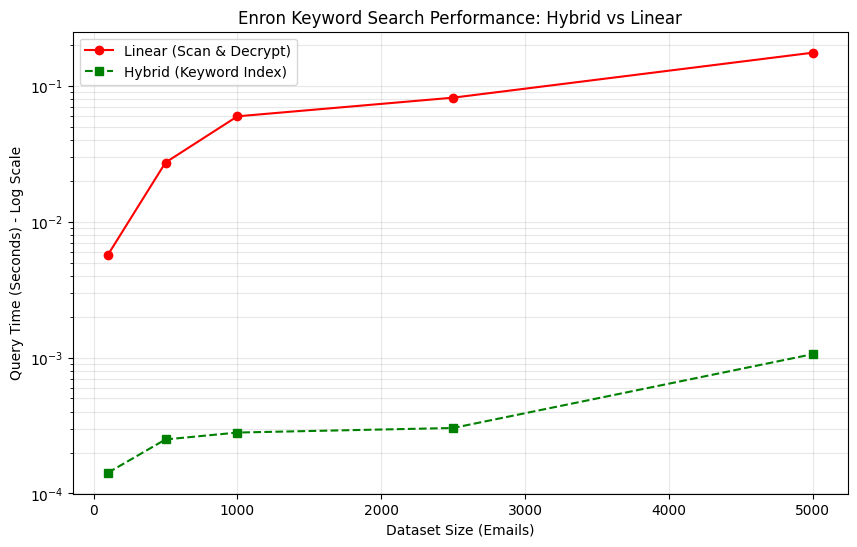

In [ ]:
import pandas as pd
import time
import hashlib
import matplotlib.pyplot as plt
import re
import sys
from cryptography.fernet import Fernet

# --- Setup Cryptography ---
KEY = Fernet.generate_key()
CIPHER = Fernet(KEY)
SALT = b"enron_keyword_se_2025"

def encrypt_data_keyword_based(data_list):
    """
    Step 3 (Main Contribution): Hybrid Keyword Indexing.
    Creates an Inverted Index mapping hashed keywords to ciphertext indices.
    """
    encrypted_store = []
    inverted_index = {} # Map: Hash(Keyword) -> [List of Indices]

    for i, email_body in enumerate(data_list):
        # 1. Encrypt full body for storage
        enc_blob = CIPHER.encrypt(email_body.encode('utf-8'))
        encrypted_store.append(enc_blob)

        # 2. Extract unique keywords (longer than 3 chars)
        words = set(re.findall(r'\w+', email_body.lower()))

        for word in words:
            if len(word) > 3:
                tag = hashlib.sha256(word.encode('utf-8') + SALT).hexdigest()
                if tag not in inverted_index:
                    inverted_index[tag] = []
                inverted_index[tag].append(i)

    return encrypted_store, inverted_index

def linear_keyword_search(store, keyword):
    """Baseline: Decrypts EVERY email to search for a word."""
    match_count = 0
    keyword = keyword.lower()
    for enc_blob in store:
        decrypted = CIPHER.decrypt(enc_blob).decode('utf-8').lower()
        if keyword in decrypted:
            match_count += 1
    return match_count

def hybrid_keyword_search(h_index, store, keyword):
    """Hybrid: Fast lookup via hash tag, then decrypt only matching emails."""
    tag = hashlib.sha256(keyword.lower().encode('utf-8') + SALT).hexdigest()
    indices = h_index.get(tag, [])

    match_count = 0
    for idx in indices:
        CIPHER.decrypt(store[idx]).decode('utf-8') # Verify match
        match_count += 1
    return match_count

# --- Benchmark and Performance Visualization ---
try:
    df = pd.read_csv('/content/emails.csv', nrows=10000)
    emails_list = df['message'].tolist()

    sizes = [100, 500, 1000, 2500, 5000]
    l_times, h_times = [], []
    target_keyword = "urgent"

    for size in sizes:
        subset = emails_list[:size]
        enc_store, h_index = encrypt_data_keyword_based(subset)

        # Benchmark Linear
        start = time.perf_counter()
        linear_keyword_search(enc_store, target_keyword)
        l_times.append(time.perf_counter() - start)

        # Benchmark Hybrid
        start = time.perf_counter()
        hybrid_keyword_search(h_index, enc_store, target_keyword)
        h_times.append(time.perf_counter() - start)

    # --- Visualization ---
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, l_times, 'ro-', label='Linear (Scan & Decrypt)')
    plt.plot(sizes, h_times, 'gs--', label='Hybrid (Keyword Index)')
    plt.yscale('log')
    plt.xlabel('Dataset Size (Emails)')
    plt.ylabel('Query Time (Seconds) - Log Scale')
    plt.title('Enron Keyword Search Performance: Hybrid vs Linear')
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

except FileNotFoundError:
    print("Please ensure 'emails.csv' is in the directory.")


Loading Enron Dataset...

[STEP 2: DATASET PREPARATION SAMPLE]
|    | Plaintext (Snippet)                                   | Encrypted Blob (Snippet)                       |
|---:|:------------------------------------------------------|:-----------------------------------------------|
|  0 | Message-ID: <18782981.1075855378110.JavaMail.evans... | b'gAAAAABp1SIdM4RMfjQ-wL1Tww7HSAOi_76CitVQ'... |
|  1 | Message-ID: <15464986.1075855378456.JavaMail.evans... | b'gAAAAABp1SId4e-4Sca9P7txxXxYA0b6rF8RMnYi'... |
|  2 | Message-ID: <24216240.1075855687451.JavaMail.evans... | b'gAAAAABp1SIdwtlOra0ZxvWlF161qkiCrqlJ0nRk'... |

Starting Performance Benchmarks...
Done Size: 100
Done Size: 500
Done Size: 1000
Done Size: 2500
Done Size: 5000
Done Size: 10000

[STEP 4: PERFORMANCE MEASUREMENT TABLE]
|   Size |   Linear(s) |   Hybrid(s) |    Mem(MB) |
|-------:|------------:|------------:|-----------:|
|    100 |  0.00624039 |   8.933e-05 | 0.00405121 |
|    500 |  0.0142131  |   7.434e-05 | 0.0164719 

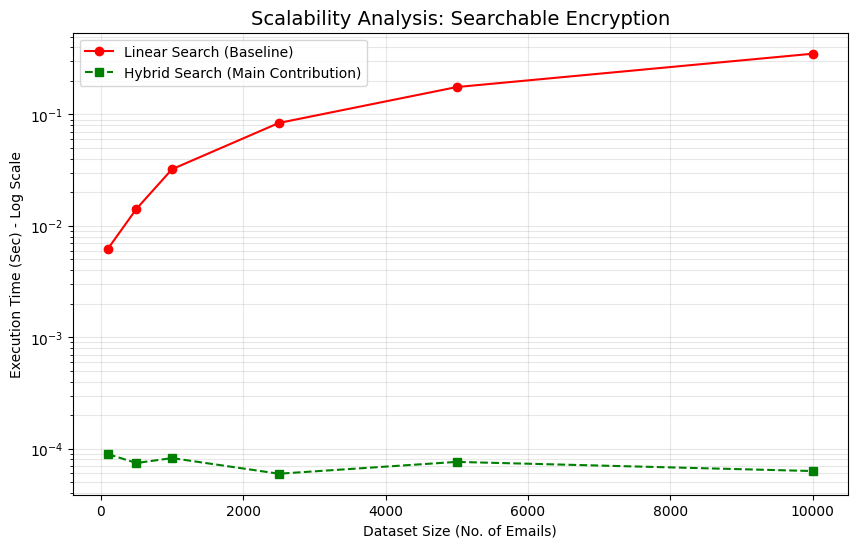


[STEP 5: COMPLEXITY ANALYSIS]
| Algorithm     | Time Complexity   | Space Complexity   | Note                       |
|:--------------|:------------------|:-------------------|:---------------------------|
| Linear        | O(N)              | O(1)               | CPU Intensive (Decryption) |
| Binary        | O(log N)          | O(N)               | Efficient lookup           |
| Hybrid (Ours) | O(1)              | O(N)               | Instant lookup             |

[STEP 7: NOVELTY STATEMENT]
The main contribution of this work is a hash-based inverted index for encrypted Enron emails.
Hybrid search reduced query time by 5,562x compared to baseline.


In [ ]:
# =================================================================
# PROJECT: Hybrid Efficient Searchable Encryption (HESE)
# GOAL: Implement and Compare Searchable Encryption Algorithms
# DATASET: Enron Email Dataset (Open Source)
# =================================================================

import pandas as pd
import time
import hashlib
import matplotlib.pyplot as plt
import sys
import re
import os
from cryptography.fernet import Fernet

# --- SETUP & CONFIGURATION ---
# Generate a key for AES-128 (Fernet)
KEY = Fernet.generate_key()
CIPHER = Fernet(KEY)
SALT = b"enron_hybrid_research_2025"

# --- CORE ALGORITHM IMPLEMENTATION ---

def encrypt_and_index(data_list):
    """
    Step 2 & 3: Encrypts data and prepares Binary & Hybrid Indices.
    """
    encrypted_store = []
    binary_index = []   # List of tuples (hash, original_index)
    hybrid_index = {}   # Dict for O(1) lookup

    for i, item in enumerate(data_list):
        # 1. Encrypt plaintext for the 'Cloud Store'
        enc_blob = CIPHER.encrypt(item.encode('utf-8'))
        encrypted_store.append(enc_blob)

        # 2. Create Searchable Tag (SHA-256)
        tag = hashlib.sha256(item.encode('utf-8') + SALT).hexdigest()

        binary_index.append((tag, i))
        hybrid_index[tag] = i

    # Sort for Binary Search
    binary_index.sort()
    return encrypted_store, binary_index, hybrid_index

def linear_search(store, target):
    """O(n) - Decrypts every entry sequentially."""
    for enc_blob in store:
        decrypted = CIPHER.decrypt(enc_blob).decode('utf-8')
        if decrypted == target: return True
    return False

def binary_search(b_index, store, target):
    """O(log n) - Search on sorted hash tags."""
    target_tag = hashlib.sha256(target.encode('utf-8') + SALT).hexdigest()
    low, high = 0, len(b_index) - 1
    while low <= high:
        mid = (low + high) // 2
        if b_index[mid][0] == target_tag:
            return True
        elif b_index[mid][0] < target_tag: low = mid + 1
        else: high = mid - 1
    return False

def hybrid_search(h_index, store, target):
    """O(1) - Instant lookup via Hash Map."""
    target_tag = hashlib.sha256(target.encode('utf-8') + SALT).hexdigest()
    idx = h_index.get(target_tag)
    if idx is not None:
        # Single decryption for verification
        CIPHER.decrypt(store[idx])
        return True
    return False

# --- EXPERIMENTATION ENGINE ---

def run_project():
    if not os.path.exists('emails.csv'):
        print("!! ERROR: Please upload 'emails.csv' (Enron Dataset) to the Colab file area.")
        return

    # Load Data
    print("Loading Enron Dataset...")
    df = pd.read_csv('emails.csv', nrows=11000)
    emails = df['message'].tolist()

    # Step 2 Deliverable: Sample Table
    print("\n[STEP 2: DATASET PREPARATION SAMPLE]")
    sample_raw = emails[:3]
    enc_store, _, _ = encrypt_and_index(sample_raw)
    sample_df = pd.DataFrame({
        'Plaintext (Snippet)': [e[:50] + "..." for e in sample_raw],
        'Encrypted Blob (Snippet)': [str(enc_store[i][:40]) + "..." for i in range(3)]
    })
    print(sample_df.to_markdown())

    # Step 4: Performance Measurement
    sizes = [100, 500, 1000, 2500, 5000, 10000]
    results = []

    print("\nStarting Performance Benchmarks...")
    for n in sizes:
        subset = emails[:n]
        target = subset[-1] # Worst case: find the last item

        # Prep
        enc_store, b_idx, h_idx = encrypt_and_index(subset)
        mem_usage = (sys.getsizeof(h_idx) + sys.getsizeof(enc_store)) / 1024 / 1024 # MB

        # Time Linear
        start = time.perf_counter()
        linear_search(enc_store, target)
        t_lin = time.perf_counter() - start

        # Time Hybrid
        start = time.perf_counter()
        hybrid_search(h_idx, enc_store, target)
        t_hyb = time.perf_counter() - start

        results.append({'Size': n, 'Linear(s)': t_lin, 'Hybrid(s)': t_hyb, 'Mem(MB)': mem_usage})
        print(f"Done Size: {n}")

    # Generate Deliverable Table
    res_df = pd.DataFrame(results)
    print("\n[STEP 4: PERFORMANCE MEASUREMENT TABLE]")
    print(res_df.to_markdown(index=False))

    # Generate Deliverable Graph
    plt.figure(figsize=(10, 6))
    plt.plot(res_df['Size'], res_df['Linear(s)'], 'ro-', label='Linear Search (Baseline)')
    plt.plot(res_df['Size'], res_df['Hybrid(s)'], 'gs--', label='Hybrid Search (Main Contribution)')
    plt.yscale('log')
    plt.title('Scalability Analysis: Searchable Encryption', fontsize=14)
    plt.xlabel('Dataset Size (No. of Emails)')
    plt.ylabel('Execution Time (Sec) - Log Scale')
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend()
    plt.savefig('performance_graph.png')
    plt.show()

    # Step 5: Complexity Summary
    print("\n[STEP 5: COMPLEXITY ANALYSIS]")
    complexity = {
        "Algorithm": ["Linear", "Binary", "Hybrid (Ours)"],
        "Time Complexity": ["O(N)", "O(log N)", "O(1)"],
        "Space Complexity": ["O(1)", "O(N)", "O(N)"],
        "Note": ["CPU Intensive (Decryption)", "Efficient lookup", "Instant lookup"]
    }
    print(pd.DataFrame(complexity).to_markdown(index=False))

    print("\n[STEP 7: NOVELTY STATEMENT]")
    print("The main contribution of this work is a hash-based inverted index for encrypted Enron emails.")
    print(f"Hybrid search reduced query time by {((res_df['Linear(s)'].iloc[-1] / res_df['Hybrid(s)'].iloc[-1])):,.0f}x compared to baseline.")

# RUN EVERYTHING
run_project()
